# Classifying Eye Diseases

This project uses deep learning to classify Eye diseases. there are only 5335 images so I am going to use transfer learning.

The data can be found on kaggle (https://www.kaggle.com/datasets/abhinav099802/eye-disease-image-dataset/data)

In [1]:
#Import the libraries
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
import torchsummary
from torchvision import models
from pathlib import Path
import torch.optim.lr_scheduler as lr_scheduler
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
base_path = os.path.normpath(os.path.join("Eye Disease", "Data", "Original_Dataset"))
print(base_path)

Eye Disease\Data\Original_Dataset


In [4]:
# Base directory relative to project root
base_dir = Path("Eye Disease/data/Original_Dataset")

image_paths = []
labels = []

# Loop through each category folder
for label in os.listdir(base_dir):
    label_dir = base_dir / label
    
    # Ensure it's a directory (skips hidden files like .DS_Store)
    if label_dir.is_dir():
        for image_name in os.listdir(label_dir):
            image_path = label_dir / image_name
            
            # Only append actual image files
            if image_path.is_file():
                image_paths.append(str(image_path))
                labels.append(label)

data_df = pd.DataFrame({"image_path": image_paths, "label": labels})
data_df.head()

,image_path,label
0,Eye Disease\data\Original_Dataset\Central Sero...,Central Serous Chorioretinopathy
1,Eye Disease\data\Original_Dataset\Central Sero...,Central Serous Chorioretinopathy
2,Eye Disease\data\Original_Dataset\Central Sero...,Central Serous Chorioretinopathy
3,Eye Disease\data\Original_Dataset\Central Sero...,Central Serous Chorioretinopathy
4,Eye Disease\data\Original_Dataset\Central Sero...,Central Serous Chorioretinopathy


In [5]:
data_df.shape

(5335, 2)

In [6]:
#Split into test train val
#split into train test and validation
train_df = data_df.sample(frac=0.7, random_state=42)
test_df = data_df.drop(train_df.index)
validation_df = test_df.sample(frac=0.5, random_state=42)
test_df = test_df.drop(validation_df.index)

In [7]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["label"])
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
class CustomImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.labels = torch.tensor(
            label_encoder.transform(self.dataframe["label"]),
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["image_path"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

In [9]:
train_dataset = CustomImageDataset(train_df, transform=transform)
val_dataset = CustomImageDataset(validation_df, transform=transform)
test_dataset = CustomImageDataset(test_df, transform=transform)

In [10]:
image, label = train_dataset[0]
print(image.shape, image.dtype, label.item(), label.dtype)
print(len(train_dataset), len(val_dataset), len(test_dataset))

torch.Size([3, 224, 224]) torch.float32 1 torch.int64
3734 800 801


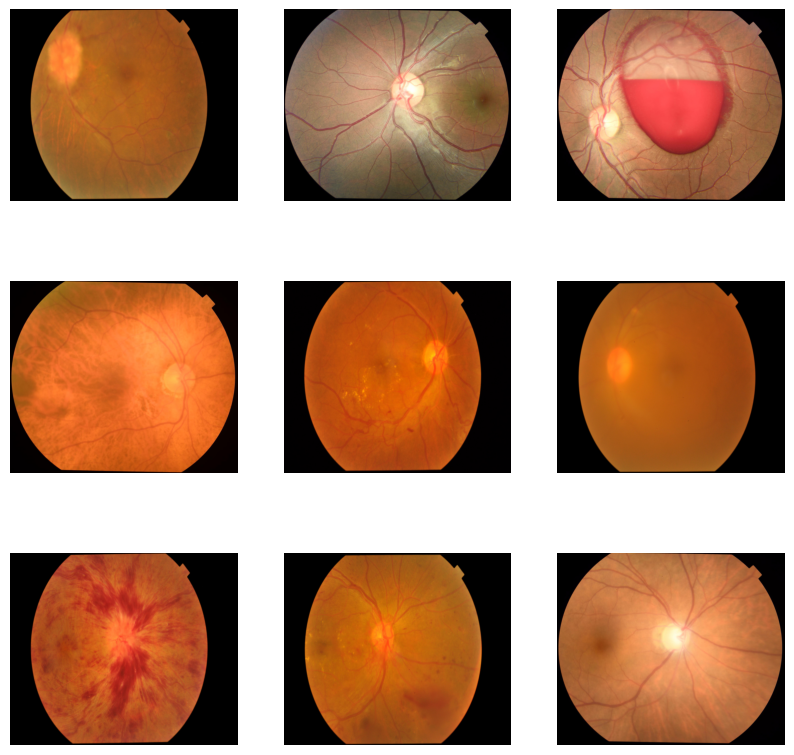

In [11]:
#Visualize a few images from the training dataset
n_rows = 3
n_cols = 3 
f, axarr = plt.subplots(n_rows, n_cols, figsize=(10, 10))
for i in range(n_rows):
    for j in range(n_cols):
        image =Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
        axarr[i, j].imshow(image)
        axarr[i, j].axis('off')
plt.show()

Baseline:

It is very easy for models to achieve high accuracy results if the dataset is heavily imbalanced. 

Before Continuing, let's look at the class idstribution and how a model that just guesses the modal class performs.

In [28]:
class_counts = data_df["label"].value_counts().sort_index()
print("class distribution (%) in the training dataset:")
class_percentages = (class_counts / class_counts.sum() * 100).round(2)
class_percentages

class distribution (%) in the training dataset:


label
Central Serous Chorioretinopathy     1.89
Diabetic Retinopathy                28.28
Disc Edema                           2.38
Glaucoma                            25.29
Healthy                             19.19
Macular Scar                         8.32
Myopia                               9.37
Pterygium                            0.32
Retinal Detachment                   2.34
Retinitis Pigmentosa                 2.61
Name: count, dtype: float64

In [29]:
# Modal-class baseline
modal_label_name = train_df["label"].mode()[0]
modal_class = label_encoder.transform([modal_label_name])[0]

def evaluate_modal_baseline(loader):
    total_correct = 0
    total_samples = 0
    total_loss = 0.0

    # Constant logits: modal class receives the highest score
    baseline_logits = torch.zeros(num_classes, device=device)
    baseline_logits[modal_class] = 1.0

    with torch.no_grad():
        for _, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            logits = baseline_logits.unsqueeze(0).expand(labels_batch.size(0), -1)

            total_loss += loss_function(logits, labels_batch).item() * labels_batch.size(0)
            total_correct += (labels_batch == modal_class).sum().item()
            total_samples += labels_batch.size(0)

    return total_correct / total_samples, total_loss / total_samples

val_baseline_accuracy, val_baseline_loss = evaluate_modal_baseline(val_loader)
test_baseline_accuracy, test_baseline_loss = evaluate_modal_baseline(test_loader)

print(f"Modal class: {modal_label_name}")
print(f"Validation baseline accuracy: {val_baseline_accuracy:.4f}")
print(f"Validation baseline loss:     {val_baseline_loss:.4f}")
print(f"Test baseline accuracy:       {test_baseline_accuracy:.4f}")
print(f"Test baseline loss:           {test_baseline_loss:.4f}")

Modal class: Diabetic Retinopathy
Validation baseline accuracy: 0.2938
Validation baseline loss:     2.1674
Test baseline accuracy:       0.2572
Test baseline loss:           2.2040


Learning

In [12]:
LR = 1e-3
EPOCHS = 40
BATCH_SIZE = 32

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [14]:
googlenet_model = models.googlenet(weights="DEFAULT")
for param in googlenet_model.parameters():
    param.requires_grad = True # all layers can learn (odd)


In [15]:
num_classes = len(train_df['label'].unique())
num_classes

10

In [16]:
googlenet_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(googlenet_model.fc.in_features, num_classes),
)
googlenet_model.to(device);

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001,

### Transfer Learning using GoogLeNet with all weights unfrozen

In [18]:
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(
    (param for param in googlenet_model.parameters() if param.requires_grad),
    lr=LR,
)
total_loss_train_plot = []
total_accuracy_train_plot = []
total_loss_val_plot = []
total_accuracy_val_plot = []

patience = 4
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    googlenet_model.train()
    total_accuracy_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = googlenet_model(inputs)
        train_loss = loss_function(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        train_accuracy = (outputs.argmax(dim=1) == labels).float().mean()
        total_accuracy_train += train_accuracy.item()
        optimizer.step()

    train_loss_epoch = total_loss_train / len(train_loader)
    train_accuracy_epoch = total_accuracy_train / len(train_loader)
    total_loss_train_plot.append(train_loss_epoch)
    total_accuracy_train_plot.append(train_accuracy_epoch)

    googlenet_model.eval()
    total_accuracy_val = 0
    total_loss_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = googlenet_model(inputs)
            val_loss = loss_function(outputs, labels)
            total_loss_val += val_loss.item()
            val_accuracy = (outputs.argmax(dim=1) == labels).float().mean()
            total_accuracy_val += val_accuracy.item()

    val_loss_epoch = total_loss_val / len(val_loader)
    val_accuracy_epoch = total_accuracy_val / len(val_loader)
    total_loss_val_plot.append(val_loss_epoch)
    total_accuracy_val_plot.append(val_accuracy_epoch)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss_epoch:.4f}, Train Accuracy: {train_accuracy_epoch:.4f} | "
        f"Val Loss: {val_loss_epoch:.4f}, Val Accuracy: {val_accuracy_epoch:.4f}"
    )

    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        patience_counter = 0
        best_model_weights = copy.deepcopy(googlenet_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}!")
            break

if best_model_weights is not None:
    googlenet_model.load_state_dict(best_model_weights)
    print(f"Loaded best model weights (Best Val Loss: {best_val_loss:.4f})")

Epoch [1/40] | Train Loss: 1.1282, Train Accuracy: 0.6174 | Val Loss: 1.0053, Val Accuracy: 0.6500
Epoch [2/40] | Train Loss: 0.8054, Train Accuracy: 0.7146 | Val Loss: 0.8826, Val Accuracy: 0.7050
Epoch [3/40] | Train Loss: 0.7343, Train Accuracy: 0.7411 | Val Loss: 1.1545, Val Accuracy: 0.6512
Epoch [4/40] | Train Loss: 0.6244, Train Accuracy: 0.7692 | Val Loss: 0.7592, Val Accuracy: 0.7312
Epoch [5/40] | Train Loss: 0.5826, Train Accuracy: 0.7932 | Val Loss: 0.9273, Val Accuracy: 0.6950
Epoch [6/40] | Train Loss: 0.5643, Train Accuracy: 0.7880 | Val Loss: 0.9923, Val Accuracy: 0.6587
Epoch [7/40] | Train Loss: 0.5128, Train Accuracy: 0.8143 | Val Loss: 0.7876, Val Accuracy: 0.7512
Epoch [8/40] | Train Loss: 0.4736, Train Accuracy: 0.8244 | Val Loss: 0.9366, Val Accuracy: 0.6663
Early stopping triggered at epoch 8!
Loaded best model weights (Best Val Loss: 0.7592)


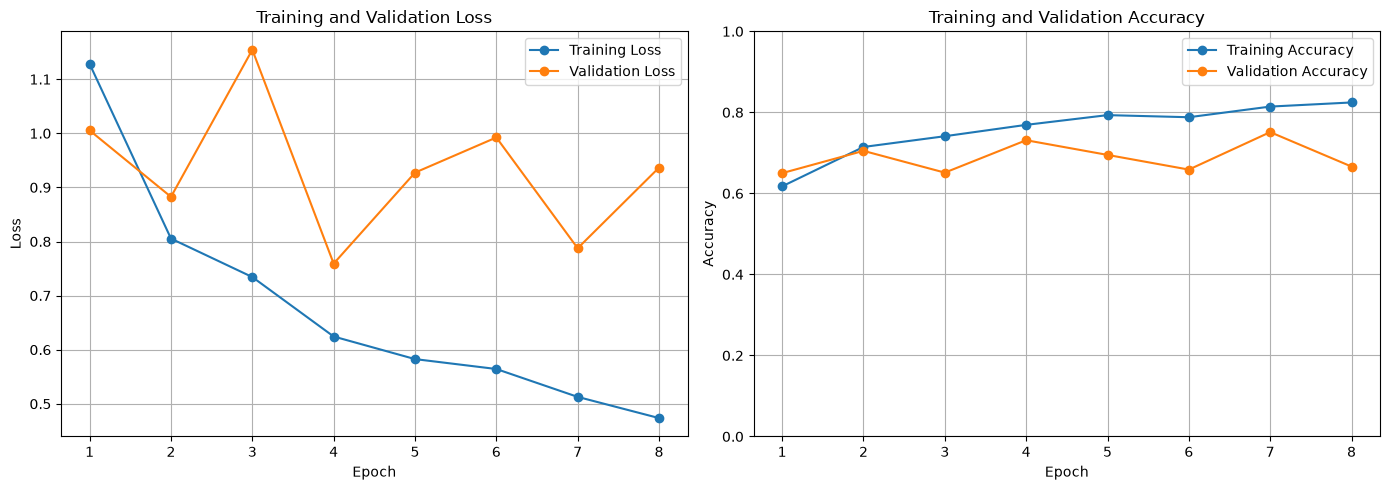

In [19]:
epochs = range(1, len(total_loss_train_plot) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss graph
axes[0].plot(epochs, total_loss_train_plot, marker="o", label="Training Loss")
axes[0].plot(epochs, total_loss_val_plot, marker="o", label="Validation Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy graph
axes[1].plot(epochs, total_accuracy_train_plot, marker="o", label="Training Accuracy")
axes[1].plot(epochs, total_accuracy_val_plot, marker="o", label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

OK, a validation loss of 0.76 and an accuracy of 0.73 is not that good, and we can see from the graph that the model is overfitting.

Let's try again with the weights frozen except the last layer.

In [20]:
googlenet_frozen_model = models.googlenet(weights="DEFAULT")
for param in googlenet_frozen_model.parameters():
    param.requires_grad = False

googlenet_frozen_model.inception5a.requires_grad_(True)
googlenet_frozen_model.inception5b.requires_grad_(True)
googlenet_frozen_model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(googlenet_frozen_model.fc.in_features, num_classes),
)
googlenet_frozen_model.to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(
    (param for param in googlenet_frozen_model.parameters() if param.requires_grad),
    lr=LR,
    weight_decay=1e-4,
)
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2,
)
total_loss_train_plot = []
total_accuracy_train_plot = []
total_loss_val_plot = []
total_accuracy_val_plot = []

patience = 4
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    googlenet_frozen_model.train()
    total_accuracy_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = googlenet_frozen_model(inputs)
        train_loss = loss_function(outputs, labels)
        total_loss_train += train_loss.item()
        train_loss.backward()
        total_accuracy_train += (outputs.argmax(dim=1) == labels).float().mean().item()
        optimizer.step()

    train_loss_epoch = total_loss_train / len(train_loader)
    train_accuracy_epoch = total_accuracy_train / len(train_loader)
    total_loss_train_plot.append(train_loss_epoch)
    total_accuracy_train_plot.append(train_accuracy_epoch)

    googlenet_frozen_model.eval()
    total_accuracy_val = 0
    total_loss_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = googlenet_frozen_model(inputs)
            val_loss = loss_function(outputs, labels)
            total_loss_val += val_loss.item()
            total_accuracy_val += (outputs.argmax(dim=1) == labels).float().mean().item()

    val_loss_epoch = total_loss_val / len(val_loader)
    val_accuracy_epoch = total_accuracy_val / len(val_loader)
    total_loss_val_plot.append(val_loss_epoch)
    total_accuracy_val_plot.append(val_accuracy_epoch)
    scheduler.step(val_loss_epoch)
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss_epoch:.4f}, Train Accuracy: {train_accuracy_epoch:.4f} | "
        f"Val Loss: {val_loss_epoch:.4f}, Val Accuracy: {val_accuracy_epoch:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        patience_counter = 0
        best_model_weights = copy.deepcopy(googlenet_frozen_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}!")
            break

if best_model_weights is not None:
    googlenet_frozen_model.load_state_dict(best_model_weights)
    print(f"Loaded best model weights (Best Val Loss: {best_val_loss:.4f})")

Epoch [1/40] | Train Loss: 1.0469, Train Accuracy: 0.6366 | Val Loss: 0.7812, Val Accuracy: 0.7063 | LR: 1.00e-03
Epoch [2/40] | Train Loss: 0.6992, Train Accuracy: 0.7407 | Val Loss: 0.7532, Val Accuracy: 0.7013 | LR: 1.00e-03
Epoch [3/40] | Train Loss: 0.5706, Train Accuracy: 0.7828 | Val Loss: 0.8267, Val Accuracy: 0.6875 | LR: 1.00e-03
Epoch [4/40] | Train Loss: 0.4942, Train Accuracy: 0.8143 | Val Loss: 0.7828, Val Accuracy: 0.7113 | LR: 1.00e-03
Epoch [5/40] | Train Loss: 0.4314, Train Accuracy: 0.8351 | Val Loss: 0.8855, Val Accuracy: 0.6925 | LR: 3.00e-04
Epoch [6/40] | Train Loss: 0.2993, Train Accuracy: 0.8852 | Val Loss: 0.8636, Val Accuracy: 0.7075 | LR: 3.00e-04
Early stopping triggered at epoch 6!
Loaded best model weights (Best Val Loss: 0.7532)


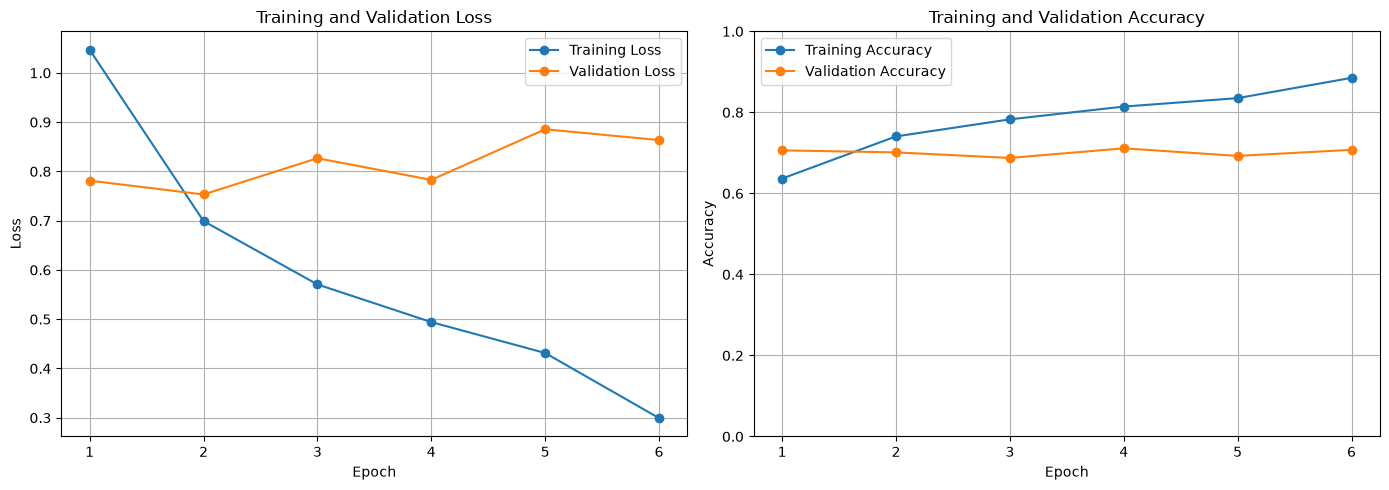

In [21]:
epochs = range(1, len(total_loss_train_plot) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss graph
axes[0].plot(epochs, total_loss_train_plot, marker="o", label="Training Loss")
axes[0].plot(epochs, total_loss_val_plot, marker="o", label="Validation Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True)

# Accuracy graph
axes[1].plot(epochs, total_accuracy_train_plot, marker="o", label="Training Accuracy")
axes[1].plot(epochs, total_accuracy_val_plot, marker="o", label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

It is overfitting, lets try data augmentation to improve generalisation.

The dowloaded data already has a folder of augmented data, but as it is was not split into train, test and validation, I did not use it due to data leakge.

 I will augment it myself using rotations, crops, brightness changing,  and Gaussian blurring

In [30]:
# Data augmentation for the training set only
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.90, 1.0)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.15),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transform

aug_train_dataset = CustomImageDataset(train_df, transform=train_transform)
aug_val_dataset = CustomImageDataset(validation_df, transform=eval_transform)
aug_test_dataset = CustomImageDataset(test_df, transform=eval_transform)

aug_train_loader = DataLoader(
    aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
aug_val_loader = DataLoader(
    aug_val_dataset, batch_size=BATCH_SIZE, shuffle=False
)
aug_test_loader = DataLoader(
    aug_test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

# Create a new pretrained GoogLeNet
googlenet_aug_model = models.googlenet(weights="DEFAULT")

# Freeze all pretrained weights
for param in googlenet_aug_model.parameters():
    param.requires_grad = False

# Fine-tune only the final inception blocks
googlenet_aug_model.inception5a.requires_grad_(True)
googlenet_aug_model.inception5b.requires_grad_(True)

# Replace the classifier
googlenet_aug_model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(googlenet_aug_model.fc.in_features, num_classes),
)

googlenet_aug_model.to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(
    filter(lambda p: p.requires_grad, googlenet_aug_model.parameters()),
    lr=3e-4,
    weight_decay=1e-4,
)

scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2,
)

aug_train_losses = []
aug_val_losses = []
aug_train_accuracies = []
aug_val_accuracies = []

best_val_loss = float("inf")
best_model_weights = None
patience_counter = 0

for epoch in range(EPOCHS):
    googlenet_aug_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels_batch in aug_train_loader:
        inputs = inputs.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = googlenet_aug_model(inputs)

        if hasattr(outputs, "logits"):
            outputs = outputs.logits

        loss = loss_function(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels_batch.size(0)
        train_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
        train_total += labels_batch.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_accuracy = train_correct / train_total

    googlenet_aug_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels_batch in aug_val_loader:
            inputs = inputs.to(device)
            labels_batch = labels_batch.to(device)

            outputs = googlenet_aug_model(inputs)

            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            loss = loss_function(outputs, labels_batch)

            val_loss += loss.item() * labels_batch.size(0)
            val_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_accuracy = val_correct / val_total

    aug_train_losses.append(epoch_train_loss)
    aug_val_losses.append(epoch_val_loss)
    aug_train_accuracies.append(epoch_train_accuracy)
    aug_val_accuracies.append(epoch_val_accuracy)

    scheduler.step(epoch_val_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Train Accuracy: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}, "
        f"Val Accuracy: {epoch_val_accuracy:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(
            googlenet_aug_model.state_dict()
        )
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_model_weights is not None:
    googlenet_aug_model.load_state_dict(best_model_weights)

Epoch [1/40] | Train Loss: 1.2090, Train Accuracy: 0.5948 | Val Loss: 0.9269, Val Accuracy: 0.6500
Epoch [2/40] | Train Loss: 0.8571, Train Accuracy: 0.6960 | Val Loss: 0.8214, Val Accuracy: 0.6987
Epoch [3/40] | Train Loss: 0.7527, Train Accuracy: 0.7266 | Val Loss: 0.7395, Val Accuracy: 0.7150
Epoch [4/40] | Train Loss: 0.6608, Train Accuracy: 0.7568 | Val Loss: 0.7087, Val Accuracy: 0.7300
Epoch [5/40] | Train Loss: 0.6216, Train Accuracy: 0.7587 | Val Loss: 0.6896, Val Accuracy: 0.7350
Epoch [6/40] | Train Loss: 0.5709, Train Accuracy: 0.7817 | Val Loss: 0.7075, Val Accuracy: 0.7225
Epoch [7/40] | Train Loss: 0.5125, Train Accuracy: 0.8018 | Val Loss: 0.7149, Val Accuracy: 0.7238
Epoch [8/40] | Train Loss: 0.4921, Train Accuracy: 0.8149 | Val Loss: 0.6985, Val Accuracy: 0.7400
Epoch [9/40] | Train Loss: 0.4076, Train Accuracy: 0.8455 | Val Loss: 0.7123, Val Accuracy: 0.7312
Early stopping triggered.


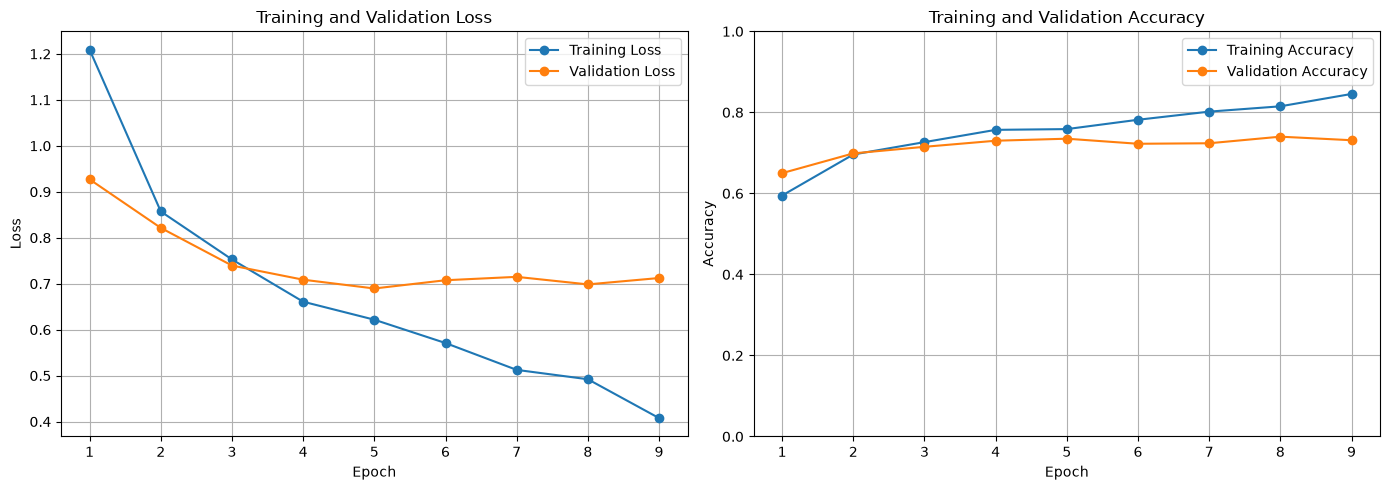

In [32]:
# Plot training and validation performance for the augmented model
epochs = range(1, len(aug_train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, aug_train_losses, marker="o", label="Training Loss")
axes[0].plot(epochs, aug_val_losses, marker="o", label="Validation Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, aug_train_accuracies, marker="o", label="Training Accuracy")
axes[1].plot(epochs, aug_val_accuracies, marker="o", label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

We can see the model is clearly better, but it starts to overfit, hence early stopping is useful.


The final model is the best, let,'s conduct the final evaluation using the test data

# Testing

Test Loss: 0.7375
Test Accuracy: 0.7253

Classification Report:
                                  precision    recall  f1-score   support

Central Serous Chorioretinopathy       0.40      0.12      0.18        17
            Diabetic Retinopathy       0.88      0.92      0.90       206
                      Disc Edema       0.93      0.57      0.70        23
                        Glaucoma       0.62      0.71      0.66       199
                         Healthy       0.71      0.72      0.72       169
                    Macular Scar       0.61      0.53      0.57        64
                          Myopia       0.63      0.60      0.61        85
                       Pterygium       1.00      1.00      1.00         4
              Retinal Detachment       0.92      0.79      0.85        14
            Retinitis Pigmentosa       0.92      0.60      0.73        20

                        accuracy                           0.73       801
                       macro avg       0.76   

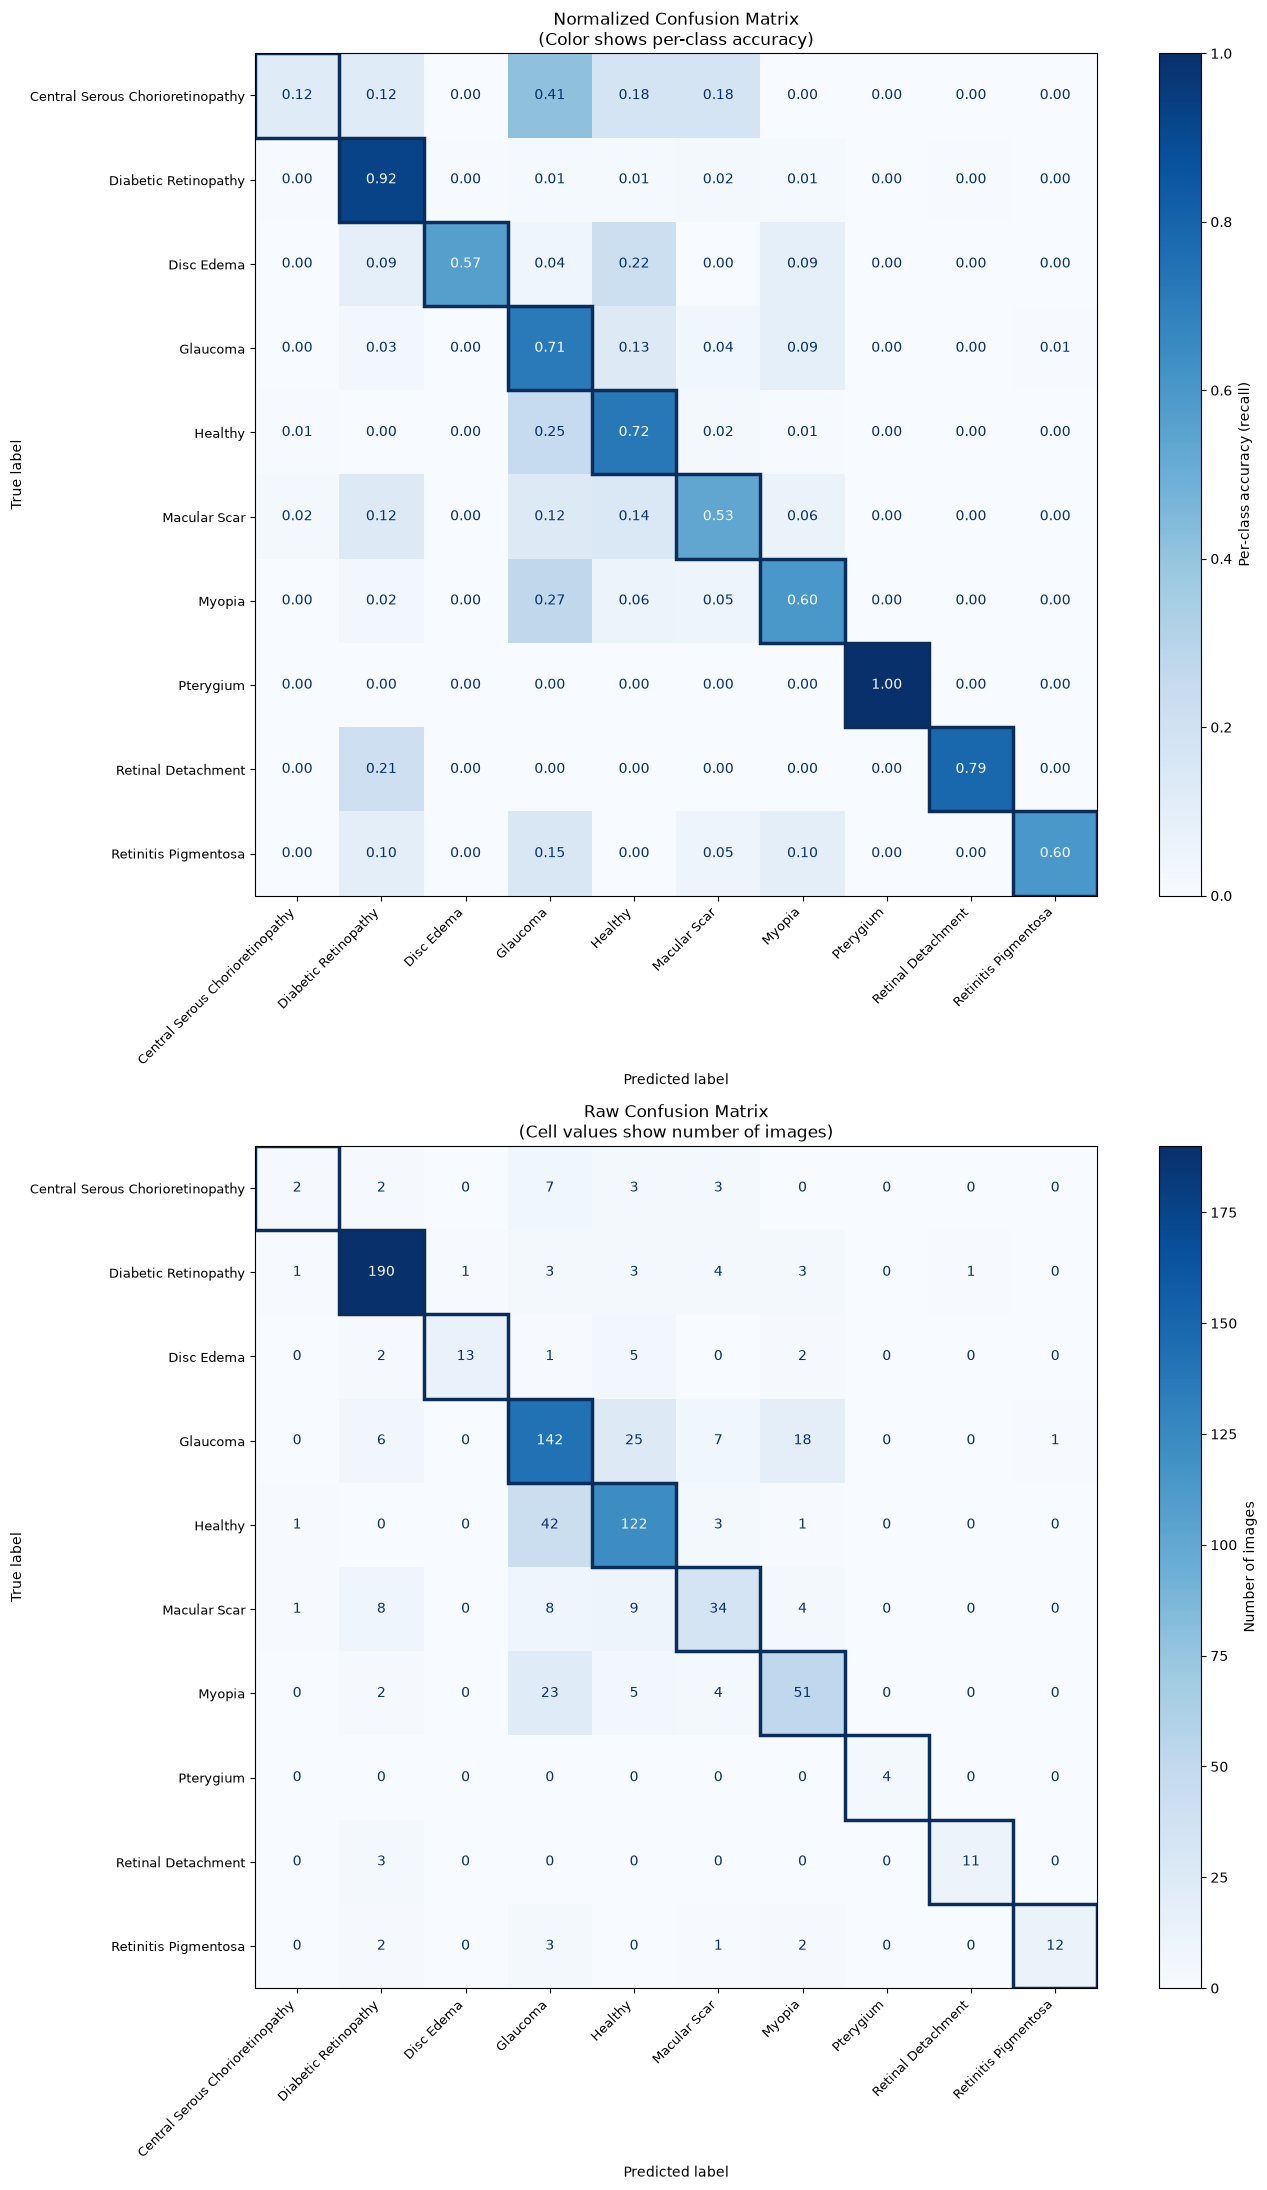

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


googlenet_aug_model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels_batch in aug_test_loader:
        inputs = inputs.to(device)
        labels_batch = labels_batch.to(device)

        outputs = googlenet_aug_model(inputs)
        if hasattr(outputs, "logits"):
            outputs = outputs.logits

        loss = loss_function(outputs, labels_batch)
        predictions = outputs.argmax(dim=1)

        test_loss += loss.item() * labels_batch.size(0)
        test_correct += (predictions == labels_batch).sum().item()
        test_total += labels_batch.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

cm = confusion_matrix(all_labels, all_predictions)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(2, 1, figsize=(14, 22))

normalized_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_,
)
normalized_display.plot(
    ax=axes[0],
    values_format=".2f",
    xticks_rotation=45,
    cmap="Blues",
    colorbar=True,
)
normalized_display.im_.colorbar.set_label("Per-class accuracy (recall)")
axes[0].set_title("Normalized Confusion Matrix\n(Color shows per-class accuracy)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

raw_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)
raw_display.plot(
    ax=axes[1],
    values_format="d",
    xticks_rotation=45,
    cmap="Blues",
    colorbar=True,
)
raw_display.im_.colorbar.set_label("Number of images")
axes[1].set_title("Raw Confusion Matrix\n(Cell values show number of images)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

for ax in axes:
    for diagonal_index in range(len(label_encoder.classes_)):
        ax.add_patch(
            plt.Rectangle(
                (diagonal_index - 0.5, diagonal_index - 0.5),
                1,
                1,
                fill=False,
                edgecolor="#0B2D5C",
                linewidth=2.5,
            )
        )
    plt.setp(ax.get_xticklabels(), ha="right", rotation=45, fontsize=9)
    plt.setp(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.show()

# Conclusion

We can see the model is very good at predicting some diseases such as diabetic retinoathy and pterygium (although pterygium had a very small class size to judge this).

However it performed very badly on central serious chorioretinopathy (CSC).  To improve this, one could change the loss function to make mistakes on CSC harshly penalized, or over sample CSC in training.

